# 03 — Experimental pipeline: 2.5D conditional localization models

This orchestration notebook trains one of the four model definitions on one of the two dataset variants.

Dataset variants:

- `no_aug`
- `intensity_aug`

Models:

- `unet`
- `attention_unet`
- `unetr`
- `swin_unet`

## 1. Imports and reusable definitions

In [1]:
import os
from pathlib import Path
import math
import time
import random
import json
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

from PIL import Image, ImageOps
import pydicom

In [2]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

## 2. Configuration

In [3]:
# Central configuration variables
# Edit these values here instead of changing parameters throughout the notebook.
BASE_DIR = Path("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification")
DATA_ROOT = BASE_DIR / "BC-data" / "data-rsna2024"
DATA_MERGED_CSV = DATA_ROOT / "data_merged.csv"
OUTPUT_DIR = BASE_DIR / "Localization-baseline" / "models" / "spinal_vertebra_localization"
CURRENT_DIR = BASE_DIR / "Localization-baseline"

FUNCTIONS_NOTEBOOK = CURRENT_DIR / "200_vertebra_localization_functions.ipynb"
DATASETS_NOTEBOOK = CURRENT_DIR / "201_vertebra_localization_datasets.ipynb"
MODELS_NOTEBOOK = CURRENT_DIR / "202_vertebra_localization_models.ipynb"

SERIES_DESCRIPTIONS = ("Sagittal T2/STIR",)
CONDITIONS = ("Spinal Canal Stenosis",)
LEVELS = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]
RSNA_SOURCE_NAME = "rsna"

USE_EXTERNAL_LOCALIZATION_COORDS = False
EXTERNAL_COORDS_CSV = BASE_DIR / "BC-data" / "data-pretraining" / "df_coords.csv"
EXTERNAL_IMAGE_ROOT = BASE_DIR / "BC-data" / "data-pretraining"
EXTERNAL_SOURCE_NAME = "external_spider"
EXTERNAL_REPLICATE_SINGLE_SLICE_TO_NUM_SLICES = True
INCLUDE_EXTERNAL_IN_PRIOR_MAPS = False

EXPERIMENT_DATASET = "no_aug"  # "no_aug" or "intensity_aug"
MODEL_NAME = "unet"  # "unet", "attention_unet", "unetr", or "swin_unet"
RANDOM_SEED = 42
VAL_FRAC = 0.15
TEST_FRAC = 0.15

IMG_SIZE = 256
NUM_SLICES = 3
SIGMA = 5.0

BATCH_SIZE = 32
EPOCHS = 40
PATIENCE = 7
LR = 1e-3
WEIGHT_DECAY = 1e-5
BASE_CHANNELS = 32
DROPOUT = 0.0
DYNAMIC_SIGMA = None  # Example: {0: 8.0, 10: 6.0, 20: 4.0}

NUM_WORKERS = 12
PIN_MEMORY = True
PERSISTENT_WORKERS = True
PREFETCH_FACTOR = 2

PRIOR_SIGMA = 8
PRIOR_EPS = 1e-4

FUSION_MODE = "log"
FUSION_LAM = 0.5
FUSION_EPS = 1e-8
PRIOR_X_RELAX_SIGMA = 28.0
PRIOR_Y_RELAX_SIGMA = 0.0

EVAL_TOLERANCE_PX = 10.0
ORDER_MARGIN_PX = 15.0

CORRECTION_TOP_K = 3
CORRECTION_NMS_RADIUS = 8
CORRECTION_MIN_CANDIDATE_SCORE = 0.0
CORRECTION_UNION_MODE = "max"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(BASE_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
def seed_everything(seed: int):
    import os, random
    import numpy as np
    import torch

    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True, warn_only=True)
    
seed_everything(RANDOM_SEED)
print("Device:", device)


Device: cuda


In [5]:
# Reusable definitions and model/dataset notebooks
%run "$FUNCTIONS_NOTEBOOK"
%run "$DATASETS_NOTEBOOK"
%run "$MODELS_NOTEBOOK"

## 3. Load metadata and create study-level split

In [6]:
df_all = pd.read_csv(DATA_MERGED_CSV)

df_loc = df_all[
    (df_all["condition"].isin(CONDITIONS)) &
    (df_all["series_description"].isin(SERIES_DESCRIPTIONS)) &
    (df_all["level"].isin(LEVELS)) &
    (df_all["x"].notna()) &
    (df_all["y"].notna()) &
    (df_all["instance_number"].notna())
].copy()

df_loc["source"] = RSNA_SOURCE_NAME

print("All merged rows:", len(df_all))
print("Localization rows after filtering:", len(df_loc))

display(df_loc.head())

print("Studies:", df_loc["study_id"].nunique())
print("Levels:")
display(df_loc["level"].value_counts().reindex(LEVELS))


All merged rows: 48677
Localization rows after filtering: 9733


,row_id,study_id,series_id,condition,level,series_description,instance_number,x,y,severity,img_path,image_height,image_width,x_norm,y_norm,source
0,4003253_spinal_canal_stenosis_l1_l2,4003253,702807833,Spinal Canal Stenosis,L1/L2,Sagittal T2/STIR,8,322.831858,227.964602,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/7...,640,640,0.504425,0.356195,rsna
1,4003253_spinal_canal_stenosis_l2_l3,4003253,702807833,Spinal Canal Stenosis,L2/L3,Sagittal T2/STIR,8,320.571429,295.714286,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/7...,640,640,0.500893,0.462054,rsna
2,4003253_spinal_canal_stenosis_l3_l4,4003253,702807833,Spinal Canal Stenosis,L3/L4,Sagittal T2/STIR,8,323.030303,371.818182,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/7...,640,640,0.504735,0.580966,rsna
3,4003253_spinal_canal_stenosis_l4_l5,4003253,702807833,Spinal Canal Stenosis,L4/L5,Sagittal T2/STIR,8,335.292035,427.327434,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/7...,640,640,0.523894,0.667699,rsna
4,4003253_spinal_canal_stenosis_l5_s1,4003253,702807833,Spinal Canal Stenosis,L5/S1,Sagittal T2/STIR,8,353.415929,483.964602,Normal/Mild,./BC-data/data-rsna2024/train_images/4003253/7...,640,640,0.552212,0.756195,rsna


Studies: 1973
Levels:


level
L1/L2    1899
L2/L3    1931
L3/L4    1970
L4/L5    1969
L5/S1    1964
Name: count, dtype: int64

## 3b. Convert external lumbar coordinate CSV into RSNA-like train rows

The external dataset from `Localization_lumbar_spine_aug` is converted to the same long localization format as `data_merged`: one row per image and lumbar level. It is then used only for training, while validation/test remain RSNA-only. Because the external images do not have neighboring-slice metadata, the custom dataset below repeats the same single image across all three 2.5D channels.


In [7]:
# Keep validation/test RSNA-only. External localization rows are train-only.
rsna_train_df, val_df, test_df = split_by_study(df_loc, val_frac=VAL_FRAC, test_frac=TEST_FRAC, seed=RANDOM_SEED)
train_df = rsna_train_df.copy()

external_loc_df = pd.DataFrame()
if USE_EXTERNAL_LOCALIZATION_COORDS:
    external_loc_df = build_external_localization_df(EXTERNAL_COORDS_CSV, EXTERNAL_IMAGE_ROOT)


print(f"RSNA train rows: {len(rsna_train_df):,} | Val rows: {len(val_df):,} | Test rows: {len(test_df):,}")
print(f"RSNA train studies: {rsna_train_df.study_id.nunique():,} | Val studies: {val_df.study_id.nunique():,} | Test studies: {test_df.study_id.nunique():,}")
print(f"External train-extension rows: {len(external_loc_df):,}")



RSNA train rows: 6,827 | Val rows: 1,447 | Test rows: 1,459
RSNA train studies: 1,381 | Val studies: 296 | Test studies: 296
External train-extension rows: 0


## 4. Create dataset and dataloaders

In [8]:
loader_generator = torch.Generator()
loader_generator.manual_seed(RANDOM_SEED)

In [9]:
base_cfg = LocalizationDatasetConfig(
    img_size=IMG_SIZE,
    num_slices=NUM_SLICES,
    sigma=SIGMA,
    use_intensity_aug=False,
    seed=RANDOM_SEED,
)

variants = make_dataset_variants(
    train_df=rsna_train_df,
    val_df=val_df,
    test_df=test_df,
    base_config=base_cfg,
)

assert EXPERIMENT_DATASET in variants, f"Choose one of {list(variants)}"

rsna_train_ds = variants[EXPERIMENT_DATASET]["train"]
val_ds = variants[EXPERIMENT_DATASET]["val"]
test_ds = variants[EXPERIMENT_DATASET]["test"]

external_train_ds = None
if USE_EXTERNAL_LOCALIZATION_COORDS and len(external_loc_df) > 0:
    external_train_ds = ExternalReplicatedSliceLocalizationDataset(
        external_loc_df,
        config=base_cfg,
        levels=LEVELS,
        use_intensity_aug=(EXPERIMENT_DATASET == "intensity_aug"),
    )
    train_ds = MixedLocalizationDataset([rsna_train_ds, external_train_ds])
else:
    train_ds = rsna_train_ds


train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    **dataloader_worker_kwargs(NUM_WORKERS),
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    **dataloader_worker_kwargs(NUM_WORKERS),
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    **dataloader_worker_kwargs(NUM_WORKERS),
)

print("Dataset variant:", EXPERIMENT_DATASET)
print("Available variants:", list(variants))
print("Train/val/test samples:", len(train_ds), len(val_ds), len(test_ds))
print("RSNA train samples:", len(rsna_train_ds))
print("External replicated train samples:", 0 if external_train_ds is None else len(external_train_ds))

if hasattr(train_ds, "df") and "source" in train_ds.df.columns:
    print("Train dataset source distribution:")
    display(train_ds.df["source"].value_counts(dropna=False))

sample = train_ds[0]
print(
    "image:", tuple(sample["image"].shape),
    "target:", tuple(sample["target"].shape),
    "level_idx:", sample["level_idx"].item(),
)


Dataset variant: no_aug
Available variants: ['no_aug', 'intensity_aug']
Train/val/test samples: 6827 1447 1459
RSNA train samples: 6827
External replicated train samples: 0
Train dataset source distribution:


source
rsna    6827
Name: count, dtype: int64

image: (3, 256, 256) target: (1, 256, 256) level_idx: 0


In [10]:
prior_train_df = train_ds.df if INCLUDE_EXTERNAL_IN_PRIOR_MAPS else rsna_train_ds.df
print("Prior maps built from rows:", len(prior_train_df))
if "source" in prior_train_df.columns:
    print("Prior-map source distribution:")
    display(prior_train_df["source"].value_counts(dropna=False))

PRIOR_MAPS = build_relative_coordinate_prior_maps_from_norm_cols(
    train_df=prior_train_df,
    img_size=IMG_SIZE,
    sigma=PRIOR_SIGMA,
    levels=LEVELS,
)

prior_maps = PRIOR_MAPS


Prior maps built from rows: 6827
Prior-map source distribution:


source
rsna    6827
Name: count, dtype: int64

Built relative-coordinate priors: (5, 256, 256)
Counts per level: {'L1/L2': 1337, 'L2/L3': 1356, 'L3/L4': 1378, 'L4/L5': 1380, 'L5/S1': 1376}


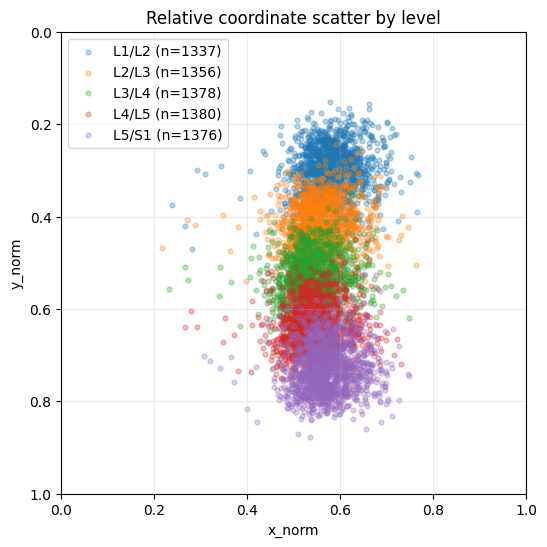

In [11]:
plot_relative_coordinate_scatter_from_norm_cols(
    train_df=train_ds.df,
    levels=LEVELS,
    alpha=0.3, 
    figsize=(6,6)
)

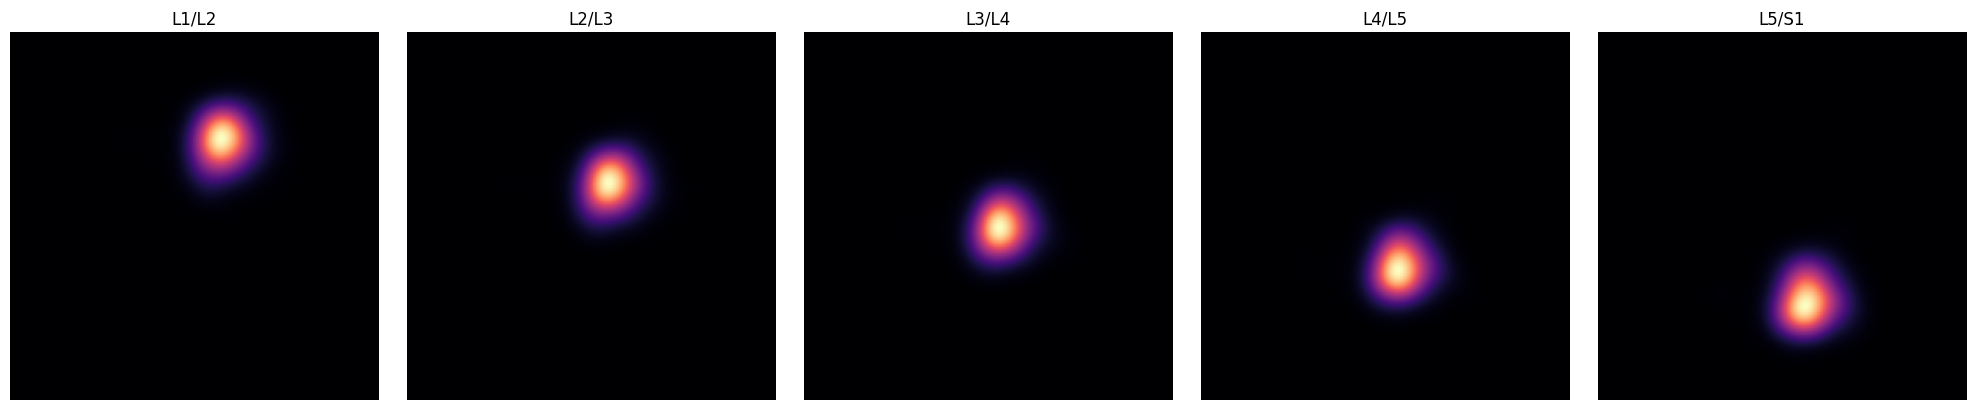

In [12]:
plot_prior_maps(PRIOR_MAPS, levels=LEVELS)

## 5. Model, optimizer, and loss

In [13]:
model = get_localization_model(
    model_name=MODEL_NAME,
    in_channels=NUM_SLICES,
    out_channels=1,
    n_levels=len(LEVELS),
    base_c=BASE_CHANNELS,
    dropout=DROPOUT,
    img_size=IMG_SIZE,
).to(device)

print(model.__class__.__name__)
print(f"Trainable parameters: {count_parameters(model):,}")

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

ConditionalUNet
Trainable parameters: 7,798,049


## 6. Training loop

In [14]:
class WeightedHeatmapMSELoss(nn.Module):

    def __init__(self, pos_weight: float):
        super().__init__()
        self.pos_weight = float(pos_weight)

    def forward(self, logits, target):
        pred = torch.sigmoid(logits)
        weights = 1.0 + self.pos_weight * target
        return (weights * (pred - target) ** 2).mean()

def coordinate_l2_loss(logits, point_xy, beta: float = 50.0):
    pred_xy = soft_argmax_2d(torch.sigmoid(logits), beta=beta)
    return torch.norm(pred_xy - point_xy, dim=1).mean()
heatmap_loss_fn = WeightedHeatmapMSELoss(pos_weight=20.0)
COORD_LOSS_WEIGHT = 0.02

def compute_loss(logits, batch):
    hm_loss = heatmap_loss_fn(logits, batch['target'])
    xy_loss = coordinate_l2_loss(logits, batch['point_xy'])
    return (hm_loss + COORD_LOSS_WEIGHT * xy_loss, {'heatmap_loss': hm_loss.item(), 'xy_loss': xy_loss.item()})


In [15]:
print("train len:", len(train_ds))
print("val len:", len(val_ds))
print("test len:", len(test_ds))

s = train_ds[0]
print("image sum:", float(s["image"].sum()))
print("target sum:", float(s["target"].sum()))
print("point_xy:", s["point_xy"])
print("level_idx:", s["level_idx"])

s = test_ds[0]
print("TEST image sum:", float(s["image"].sum()))
print("TEST target sum:", float(s["target"].sum()))
print("TEST point_xy:", s["point_xy"])
print("TEST level_idx:", s["level_idx"])

train len: 6827
val len: 1447
test len: 1459
image sum: 31213.947265625
target sum: 157.2435760498047
point_xy: tensor([129.1327,  91.1858])
level_idx: tensor(0)
TEST image sum: 48409.6171875
TEST target sum: 158.0500946044922
TEST point_xy: tensor([118.7059,  68.4706])
TEST level_idx: tensor(0)


In [16]:
from tqdm.auto import tqdm

model, history_df, ckpt_path = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    epochs=EPOCHS,
    patience=PATIENCE,
    output_dir=OUTPUT_DIR,
    dynamic_sigma=DYNAMIC_SIGMA,
)

display(history_df.tail())
history_csv = OUTPUT_DIR / f"history_{MODEL_NAME}_{EXPERIMENT_DATASET}.csv"
history_df.to_csv(history_csv, index=False)
print("Saved history:", history_csv)

train:   0%|          | 0/214 [00:00<?, ?it/s]

val:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 001/40 | train 0.40720 | val 0.20859 | sigma 5.00 | n_levels 5 | 26.7s
  saved: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Localization-baseline/models/spinal_vertebra_localization/best_unet_no_aug.pt


train:   0%|          | 0/214 [00:00<?, ?it/s]

val:   0%|          | 0/46 [00:00<?, ?it/s]

...

train:   0%|          | 0/214 [00:00<?, ?it/s]

val:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 034/40 | train 0.03350 | val 0.05858 | sigma 5.00 | n_levels 5 | 24.4s
Early stopping.


,epoch,train_loss,val_loss,train_heatmap_loss,val_heatmap_loss,train_xy_loss,val_xy_loss,seconds,sigma,n_levels
29,29,0.033275,0.058879,0.002246,0.002470,1.551438,2.820441,24.307561,5.0,5
30,30,0.038956,0.069523,0.002529,0.003325,1.821344,3.309916,24.568038,5.0,5
31,31,0.043468,0.060932,0.002797,0.002553,2.033522,2.918949,24.516513,5.0,5
32,32,0.035718,0.060180,0.002347,0.002438,1.668533,2.887117,24.481681,5.0,5
33,33,0.033499,0.058581,0.002234,0.002678,1.563216,2.795152,24.432023,5.0,5


Saved history: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Localization-baseline/models/spinal_vertebra_localization/history_unet_no_aug.csv


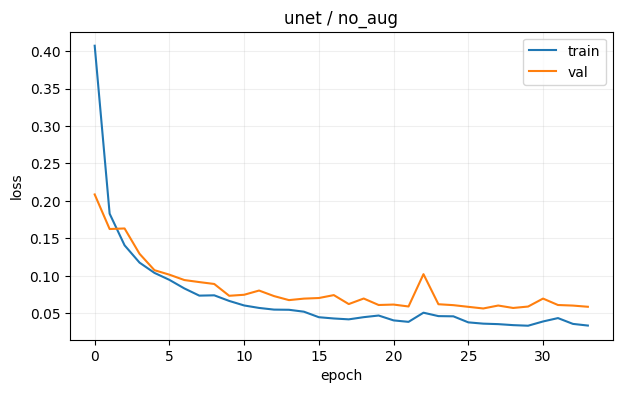

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"{MODEL_NAME} / {EXPERIMENT_DATASET}")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

## 7. Evaluation

In [18]:
test_raw = generate_raw_heatmaps_from_loader(
    model=model,
    loader=test_loader,
    device=device,
    apply_sigmoid=True,
)

Generating raw heatmaps:   0%|          | 0/46 [00:00<?, ?it/s]

In [19]:
#BASIC ARGMAX EVAL
import numpy as np
import pandas as pd

TOL = EVAL_TOLERANCE_PX

rows = []

for idx in range(len(test_ds)):
    sample = test_ds[idx]

    # GT point in model/image space
    gt = sample["point_xy"]
    if hasattr(gt, "detach"):
        gt = gt.detach().cpu().numpy()
    gt_x, gt_y = float(gt[0]), float(gt[1])

    # Raw prediction
    raw_hmap = test_raw["heatmaps"][idx]
    pred_x, pred_y, raw_conf = _argmax_xy_value(raw_hmap)

    # Level
    level_idx = int(test_raw["level_idx"][idx])
    level_name = LEVELS[level_idx]

    dist_px = np.sqrt((pred_x - gt_x) ** 2 + (pred_y - gt_y) ** 2)

    rows.append({
        "idx": idx,
        "level_idx": level_idx,
        "level": level_name,
        "gt_x": gt_x,
        "gt_y": gt_y,
        "pred_x": pred_x,
        "pred_y": pred_y,
        "dist_px": dist_px,
        "within_10px": dist_px <= TOL,
        "raw_conf": raw_conf,
    })

test_raw_eval_df = pd.DataFrame(rows)

print(f"Raw predictions — Within {int(TOL)}px: {test_raw_eval_df['within_10px'].sum()} / {len(test_raw_eval_df)}")
print(f"Hit rate: {test_raw_eval_df['within_10px'].mean() * 100:.2f}%")
print(f"Mean distance: {test_raw_eval_df['dist_px'].mean():.2f}px")
print(f"Median distance: {test_raw_eval_df['dist_px'].median():.2f}px")

Raw predictions — Within 10px: 1152 / 1459
Hit rate: 78.96%
Mean distance: 8.09px
Median distance: 2.27px


In [20]:
raw_summary_by_level = test_raw_eval_df.groupby("level").agg(
    n=("dist_px", "size"),
    within_10px=("within_10px", "sum"),
    hit_rate=("within_10px", "mean"),
    mean_dist=("dist_px", "mean"),
    median_dist=("dist_px", "median"),
    mean_raw_conf=("raw_conf", "mean"),
).sort_index()

raw_summary_by_level

,n,within_10px,hit_rate,mean_dist,median_dist,mean_raw_conf
level,,,,,,
L1/L2,284,72,0.253521,23.977385,29.527625,0.999998
L2/L3,290,221,0.762069,8.873419,2.367726,0.999997
L3/L4,296,290,0.979730,2.444274,1.902986,0.992839
L4/L5,294,284,0.965986,2.731005,1.915102,0.997026
L5/S1,295,285,0.966102,3.007169,1.848773,0.997698


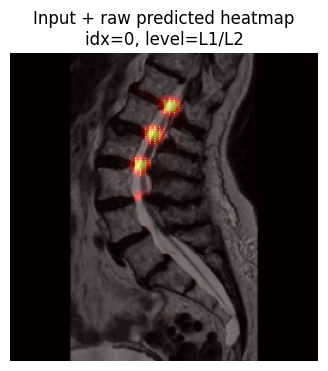

In [21]:
idx = 0

sample = test_ds[idx]
image = sample["image"]
image_2d = tensor_to_numpy_image(image, channel=image.shape[0] // 2)

hmap = test_raw["heatmaps"][idx]
level_idx = int(test_raw["level_idx"][idx])
level_name = LEVELS[level_idx]

plt.figure(figsize=(4,4))
plt.imshow(image_2d, cmap="gray")
plt.imshow(hmap, cmap="hot", alpha=0.55)
plt.title(f"Input + raw predicted heatmap\nidx={idx}, level={level_name}")
plt.axis("off")
plt.show()

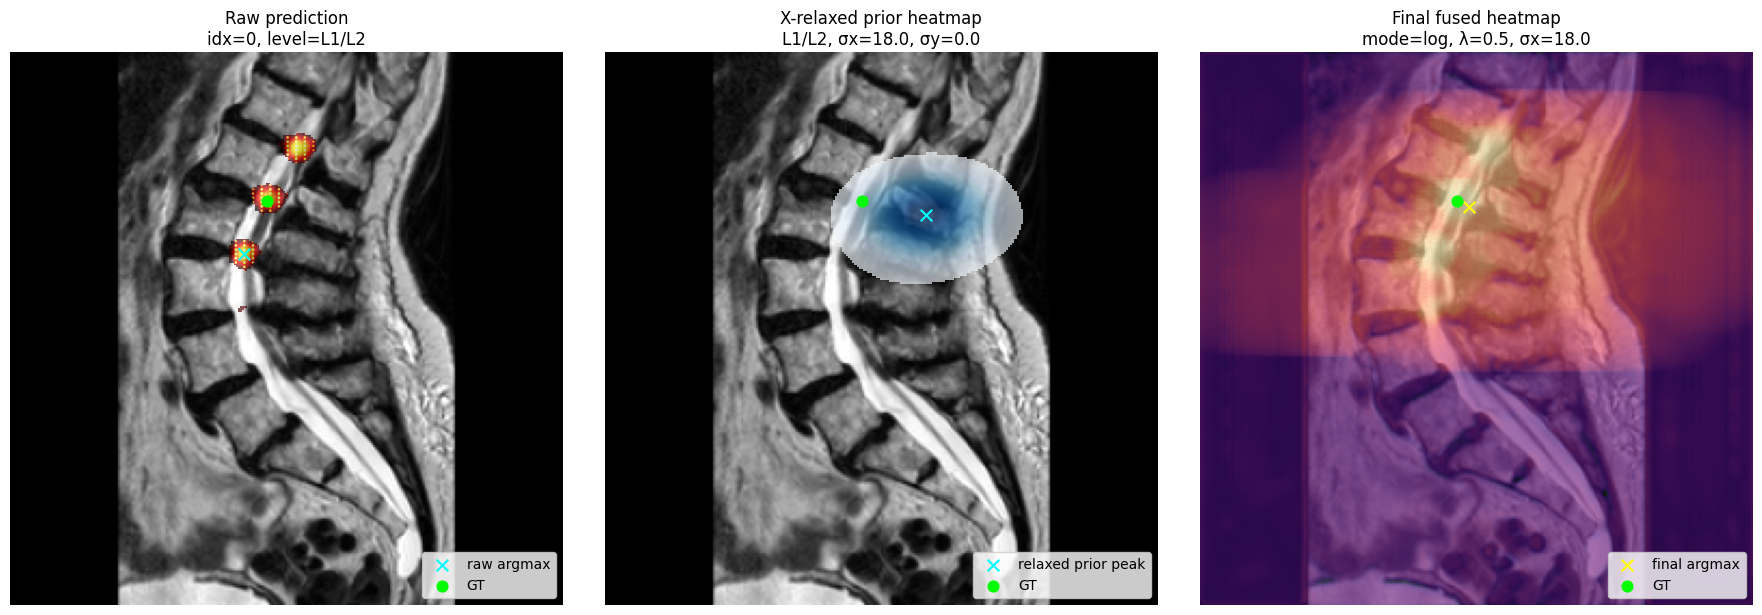

idx: 0
level: L1/L2 (level_idx=0)
GT point:     (118.71, 68.47)
Raw argmax:   (108.00, 93.00) conf=1.0000
Prior peak:   (148.00, 75.00) conf=1.0000
Final argmax: (124.00, 71.00) conf=1.0000


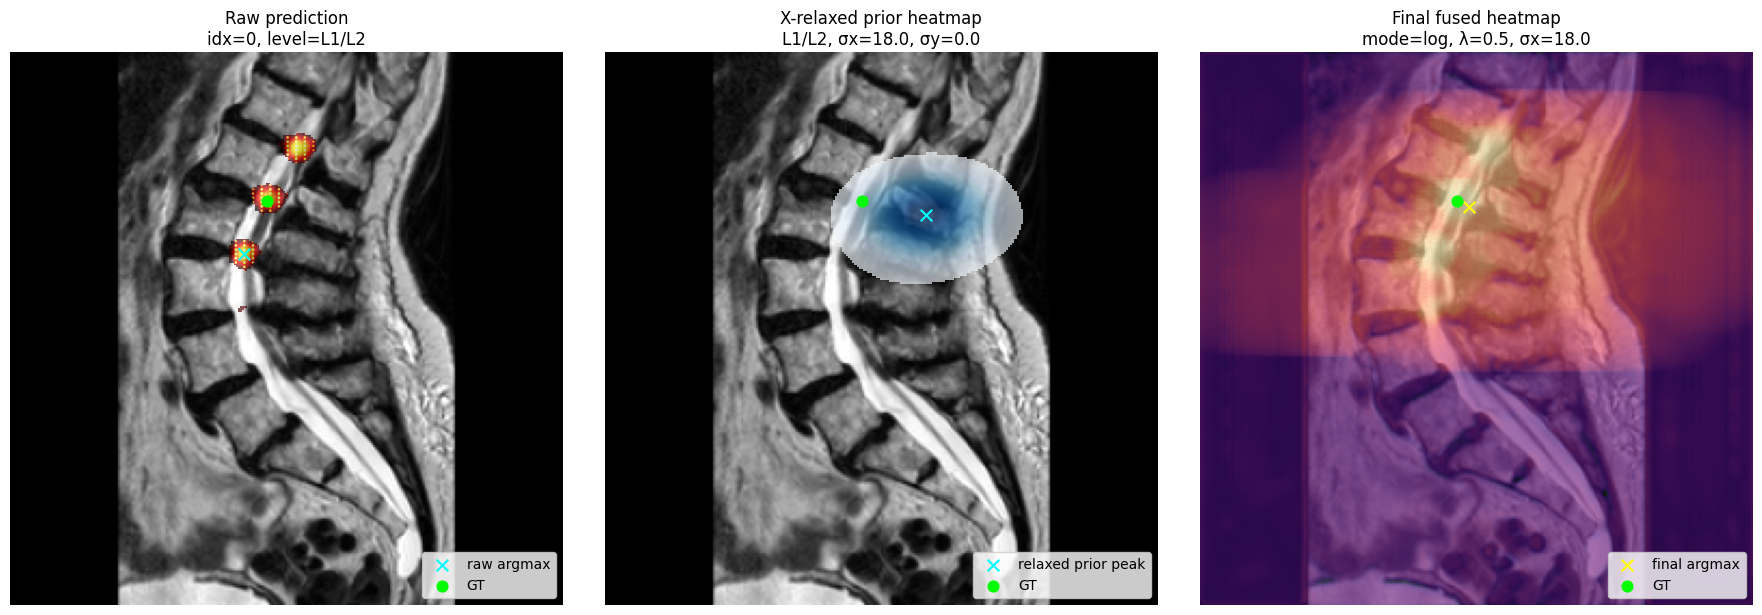

idx: 0
level: L1/L2 (level_idx=0)
GT point:     (118.71, 68.47)
Raw argmax:   (108.00, 93.00) conf=1.0000
Prior peak:   (148.00, 75.00) conf=1.0000
Final argmax: (124.00, 71.00) conf=1.0000


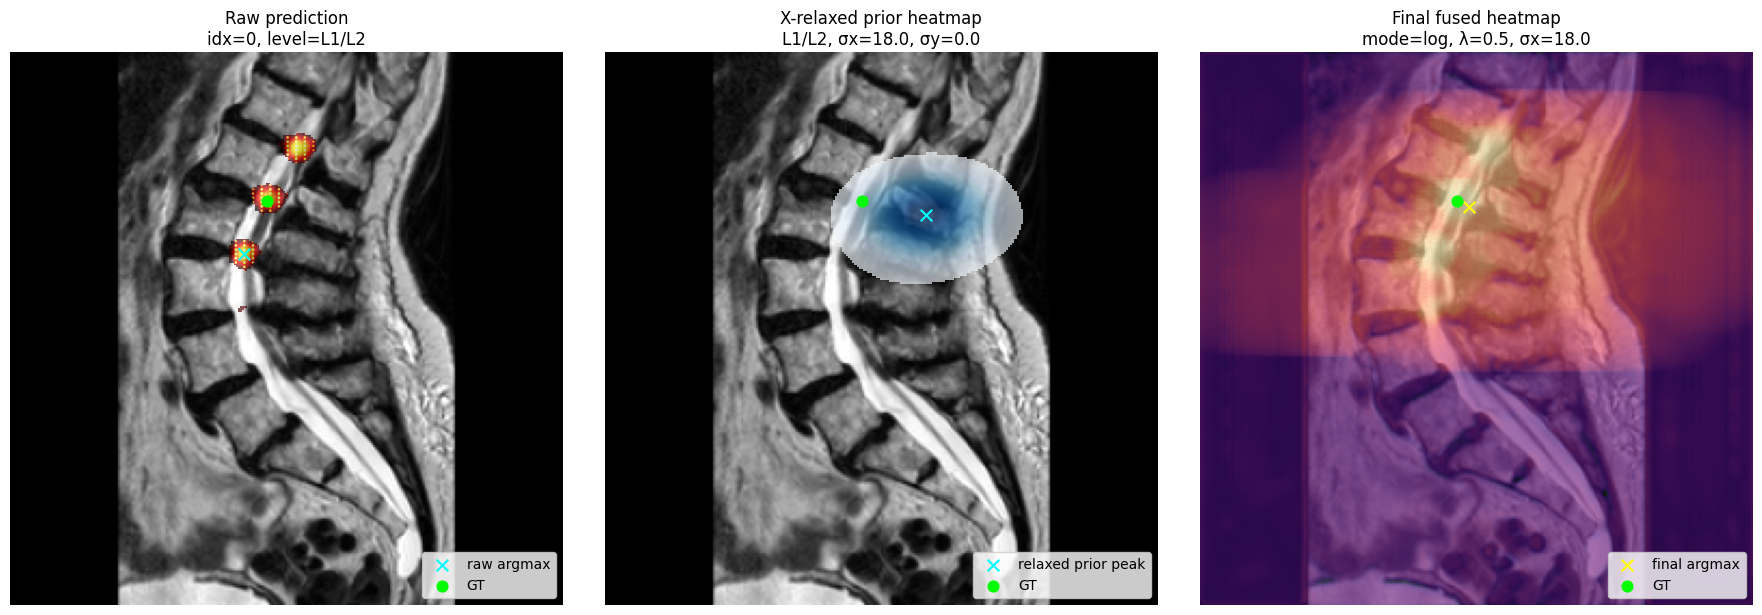

idx: 0
level: L1/L2 (level_idx=0)
GT point:     (118.71, 68.47)
Raw argmax:   (108.00, 93.00) conf=1.0000
Prior peak:   (148.00, 75.00) conf=1.0000
Final argmax: (124.00, 71.00) conf=1.0000


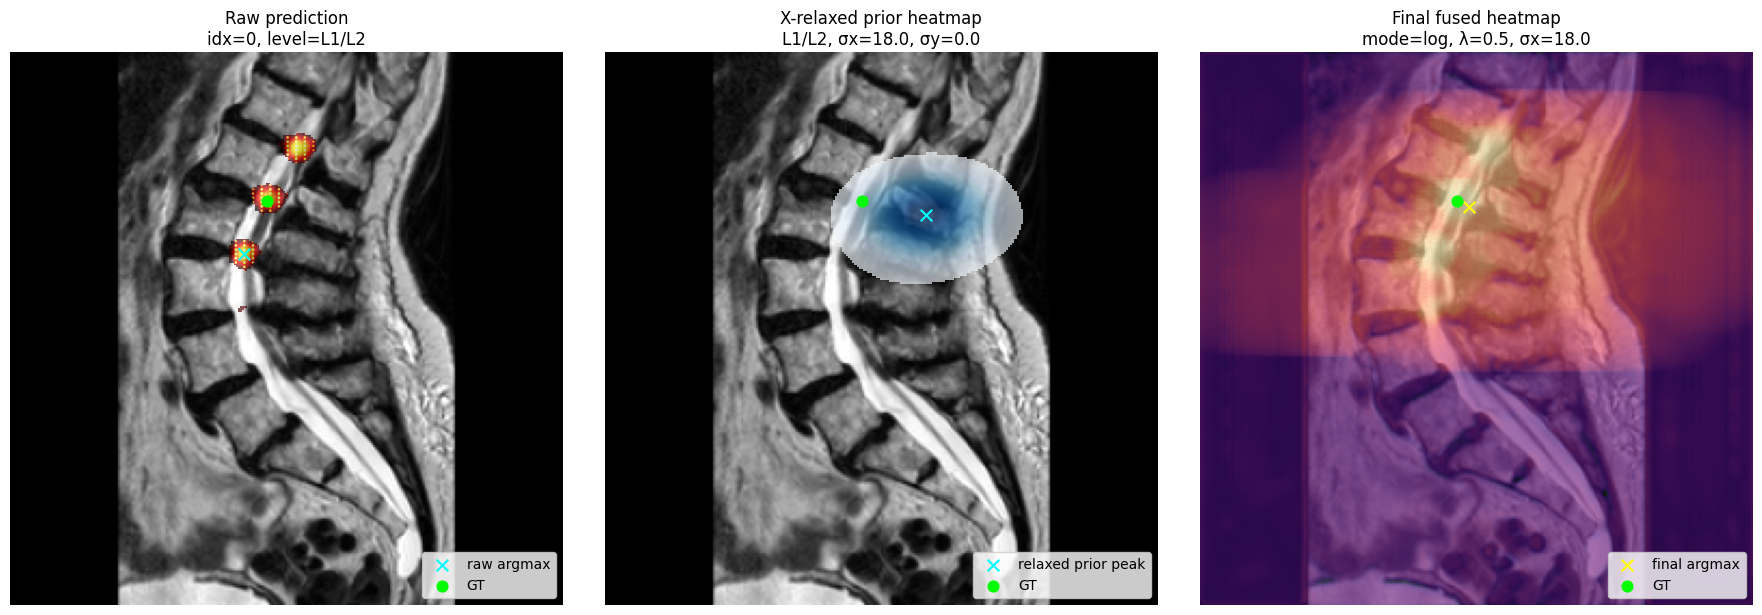

idx: 0
level: L1/L2 (level_idx=0)
GT point:     (118.71, 68.47)
Raw argmax:   (108.00, 93.00) conf=1.0000
Prior peak:   (148.00, 75.00) conf=1.0000
Final argmax: (124.00, 71.00) conf=1.0000


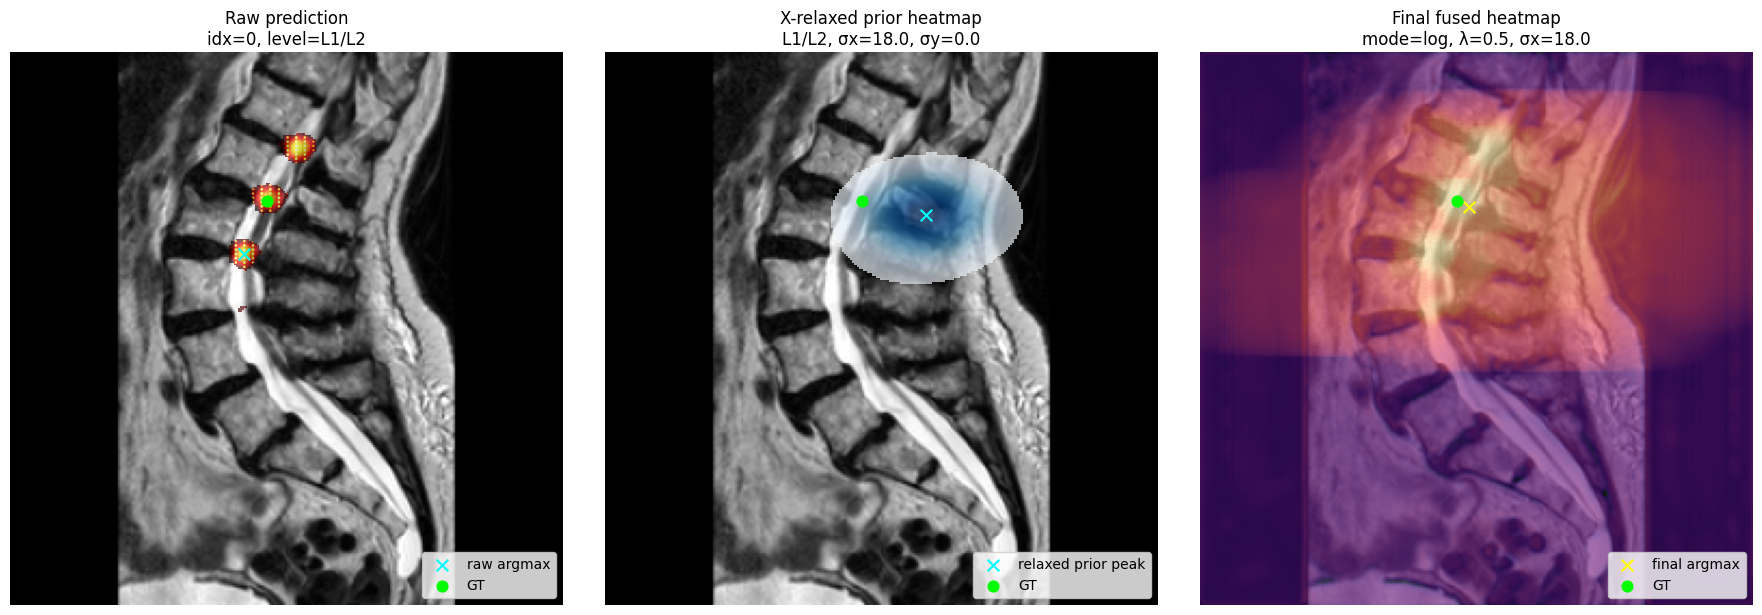

idx: 0
level: L1/L2 (level_idx=0)
GT point:     (118.71, 68.47)
Raw argmax:   (108.00, 93.00) conf=1.0000
Prior peak:   (148.00, 75.00) conf=1.0000
Final argmax: (124.00, 71.00) conf=1.0000


In [22]:
for idx in range(5):
    plot_raw_prior_final_masked(
    idx=0,
    dataset=test_ds,
    raw_preds=test_raw,
    prior_maps=PRIOR_MAPS,
    lam=0.5,
    eps=1e-8,
    fusion_mode="log",
    alpha=0.65,
    raw_threshold=0.25,
    prior_threshold=0.15,
    fused_threshold=0.25,
    prior_x_relax_sigma=18.0,
    prior_y_relax_sigma=0.0,
        
    )

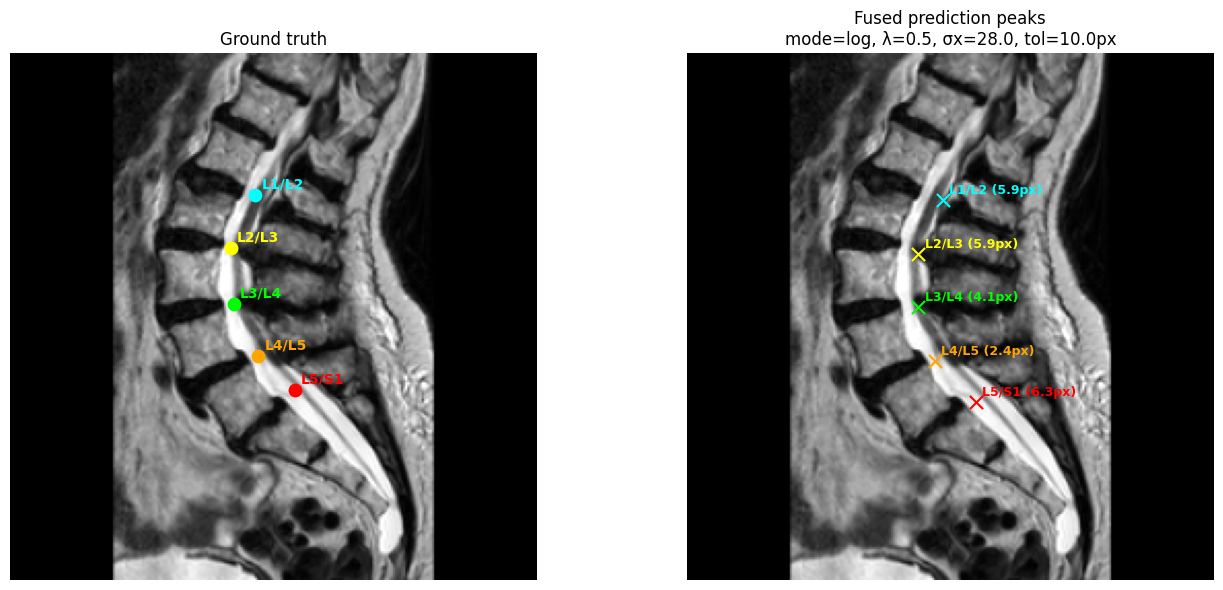

Grouping columns used: ['study_id', 'series_id', 'instance_number', 'condition']
Anchor idx: 0
Matched rows: 5

Within 10.0px:
5 / 5


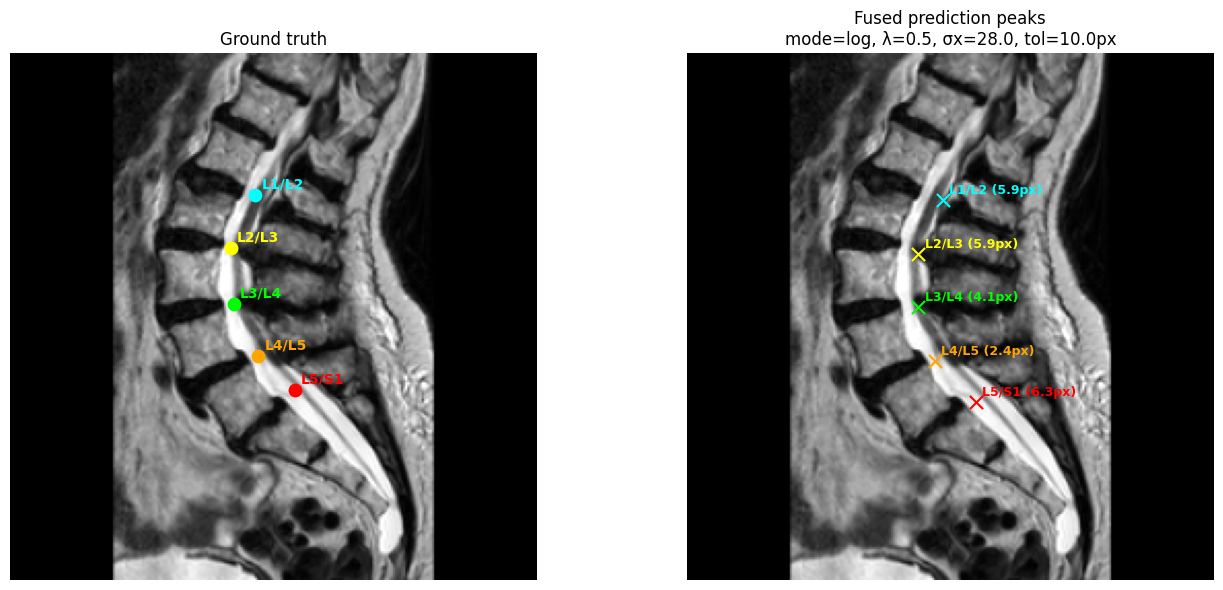

Grouping columns used: ['study_id', 'series_id', 'instance_number', 'condition']
Anchor idx: 1
Matched rows: 5

Within 10.0px:
5 / 5


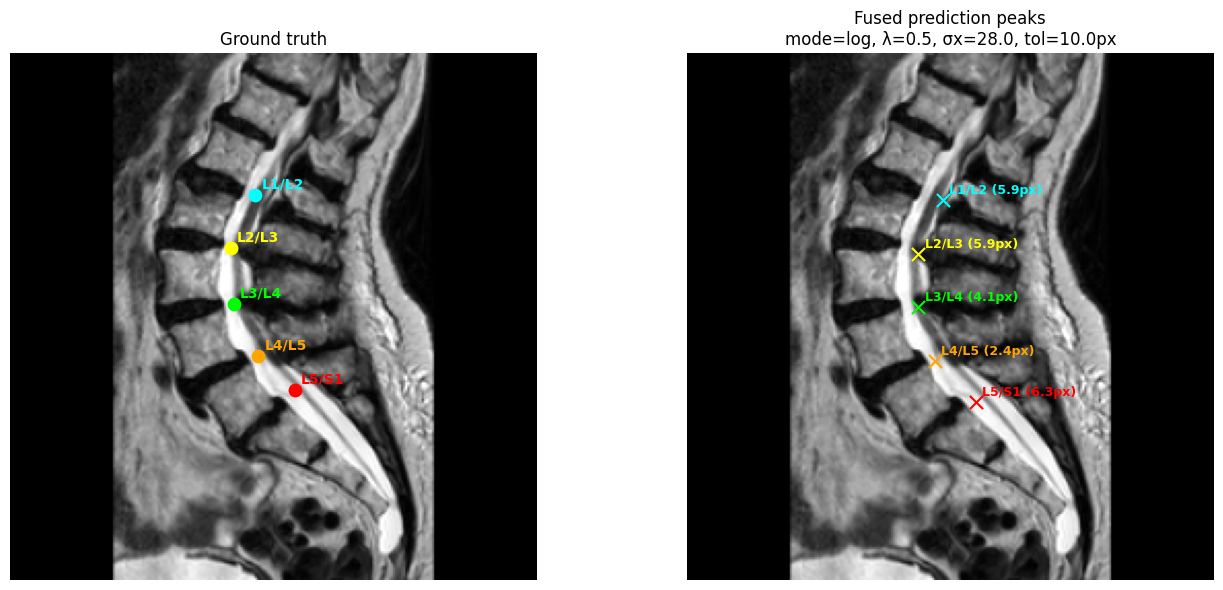

Grouping columns used: ['study_id', 'series_id', 'instance_number', 'condition']
Anchor idx: 2
Matched rows: 5

Within 10.0px:
5 / 5


In [23]:
for anchor_idx in range(3):
    peak_df = plot_gt_vs_fused_peaks(
        anchor_idx=anchor_idx,
        dataset=test_ds,
        raw_preds=test_raw,
        prior_maps=PRIOR_MAPS,
        lam=FUSION_LAM,
        fusion_mode=FUSION_MODE,
        eps=FUSION_EPS,
        group_cols=None,
        prior_x_relax_sigma=PRIOR_X_RELAX_SIGMA,
        prior_y_relax_sigma=PRIOR_Y_RELAX_SIGMA,
        tolerance_px=EVAL_TOLERANCE_PX
        )

In [24]:
TOL = EVAL_TOLERANCE_PX

rows = []
test_meta_df = test_ds.df.reset_index(drop=True)

for idx in range(len(test_ds)):
    sample = test_ds[idx]
    meta = test_meta_df.loc[idx].to_dict()

    # ground truth
    gt = sample["point_xy"]
    if hasattr(gt, "detach"):
        gt = gt.detach().cpu().numpy()

    gt_x, gt_y = float(gt[0]), float(gt[1])

    # level
    level_idx = int(test_raw["level_idx"][idx])
    level_name = LEVELS[level_idx]

    # raw + prior fusion
    raw_hmap = test_raw["heatmaps"][idx]
    prior_hmap = PRIOR_MAPS[level_idx]

    fused_score, fused_n, raw_n, prior_relaxed = _fuse_heatmap_with_scores(
        raw_hmap=raw_hmap,
        prior_hmap=prior_hmap,
        lam=FUSION_LAM,
        mode=FUSION_MODE,
        prior_x_relax_sigma=PRIOR_X_RELAX_SIGMA,
        prior_y_relax_sigma=PRIOR_Y_RELAX_SIGMA,
        eps=FUSION_EPS,
    )

    pred_x, pred_y, fused_score_at_pred = _argmax_xy_value(fused_score)

    dist_px = np.sqrt((pred_x - gt_x) ** 2 + (pred_y - gt_y) ** 2)

    out = {
        "idx": idx,
        "level_idx": level_idx,
        "level": level_name,

        "gt_x": gt_x,
        "gt_y": gt_y,

        "pred_x": pred_x,
        "pred_y": pred_y,

        "dist_px": dist_px,
        "within_10px": dist_px <= TOL,
        "outside_10px": dist_px > TOL,
        "has_gt": True,
    }

    # stable merge metadata
    for c in [
        "study_id",
        "series_id",
        "instance_number",
        "condition",
        "series_description",
        "img_path",
    ]:
        if c in meta:
            out[c] = meta[c]

    rows.append(out)

test_eval_df = pd.DataFrame(rows)

In [25]:
test_eval_df.groupby("level").agg(
    n=("dist_px", "size"),
    within_10px=("within_10px", "sum"),
    hit_rate=("within_10px", "mean"),
    mean_dist=("dist_px", "mean"),
    median_dist=("dist_px", "median"),
)

,n,within_10px,hit_rate,mean_dist,median_dist
level,,,,,
L1/L2,284,194,0.683099,12.046302,7.008363
L2/L3,290,204,0.703448,11.490068,6.678806
L3/L4,296,285,0.962838,4.129797,3.413645
L4/L5,294,287,0.976190,4.525070,4.196219
L5/S1,295,285,0.966102,5.397062,4.480931


## 8. Predict all 5 vertebras for all study_ids

In [26]:
test_anchor_df, group_cols = get_inference_anchor_indices(test_ds)

test_all5_pred_df, raw_heatmaps = predict_all_5_levels_for_dataset(
    dataset=test_ds,
    model=model,
    device=device,
    prior_maps=PRIOR_MAPS,
    anchor_df=test_anchor_df,
    lam=FUSION_LAM,
    fusion_mode=FUSION_MODE,
    prior_x_relax_sigma=PRIOR_X_RELAX_SIGMA,
    prior_y_relax_sigma=PRIOR_Y_RELAX_SIGMA,
    eps=FUSION_EPS,
)

Predicting all 5 levels:   0%|          | 0/376 [00:00<?, ?it/s]

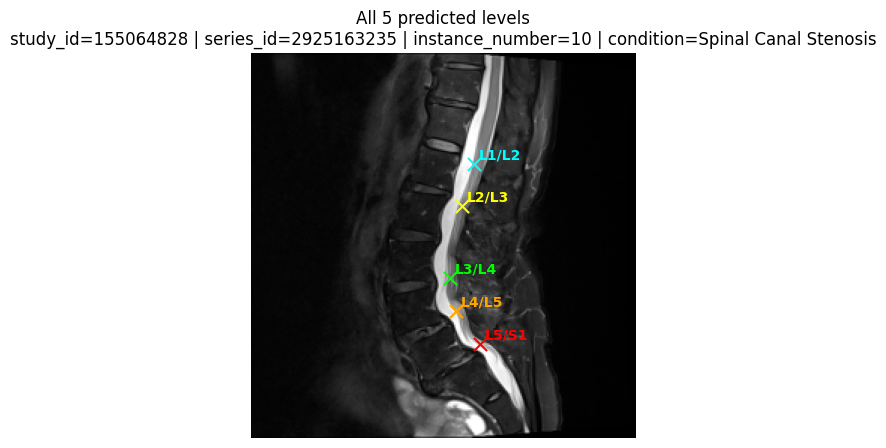

In [27]:
plot_all5_predictions_for_anchor(
    anchor_idx=test_anchor_df["anchor_idx"].iloc[8],
    pred_df=test_all5_pred_df,
    dataset=test_ds,
)

In [28]:
import numpy as np
import pandas as pd

TOL = EVAL_TOLERANCE_PX

# Ground truth table from your test dataset
gt_df = test_ds.df.reset_index(drop=True).copy()

# Keep only columns needed for matching + GT coordinates
match_cols = [c for c in ["study_id", "series_id", "instance_number", "condition", "level"] if c in gt_df.columns]

gt_keep_cols = match_cols + ["point_xy"] if "point_xy" in gt_df.columns else match_cols

# If point_xy is not in df, use x/y converted to resized model coordinates if available.
# In your dataset samples point_xy exists, but df usually has x, y, x_norm, y_norm.
# Here we build GT coordinates in model space from x_norm/y_norm.
gt_eval = gt_df[match_cols + ["x_norm", "y_norm"]].copy()
gt_eval["gt_x"] = gt_eval["x_norm"] * (IMG_SIZE - 1)
gt_eval["gt_y"] = gt_eval["y_norm"] * (IMG_SIZE - 1)

gt_eval = gt_eval[match_cols + ["gt_x", "gt_y"]].drop_duplicates(match_cols)

# Merge all-5 predictions with available GT
eval_all5 = test_all5_pred_df.merge(
    gt_eval,
    on=match_cols,
    how="left",
    indicator=True,
)

eval_all5["has_gt"] = eval_all5["_merge"].eq("both")

# Distance only where GT exists
eval_all5["dist_px"] = np.nan
mask_gt = eval_all5["has_gt"]

eval_all5.loc[mask_gt, "dist_px"] = np.sqrt(
    (eval_all5.loc[mask_gt, "pred_x"] - eval_all5.loc[mask_gt, "gt_x"]) ** 2
    + (eval_all5.loc[mask_gt, "pred_y"] - eval_all5.loc[mask_gt, "gt_y"]) ** 2
)

eval_all5["within_10px"] = False
eval_all5.loc[mask_gt, "within_10px"] = eval_all5.loc[mask_gt, "dist_px"] <= TOL

eval_all5["outside_10px"] = False
eval_all5.loc[mask_gt, "outside_10px"] = eval_all5.loc[mask_gt, "dist_px"] > TOL

# Counts
n_total_predictions = len(eval_all5)
n_no_gt = int((~eval_all5["has_gt"]).sum())
n_with_gt = int(eval_all5["has_gt"].sum())
n_within = int(eval_all5["within_10px"].sum())
n_outside = int(eval_all5["outside_10px"].sum())

print(f"Total predictions:              {n_total_predictions}")
print(f"Predictions with GT annotation: {n_with_gt}")
print(f"Predictions without GT:         {n_no_gt}")
print(f"Within {int(TOL)}px:             {n_within}")
print(f"Outside {int(TOL)}px:            {n_outside}")

if n_with_gt > 0:
    print(f"Hit rate on annotated points:   {n_within / n_with_gt * 100:.2f}%")
    print(f"Mean distance on GT points:     {eval_all5.loc[mask_gt, 'dist_px'].mean():.2f}px")
    print(f"Median distance on GT points:   {eval_all5.loc[mask_gt, 'dist_px'].median():.2f}px")

Total predictions:              1880
Predictions with GT annotation: 1459
Predictions without GT:         421
Within 10px:             1258
Outside 10px:            201
Hit rate on annotated points:   86.22%
Mean distance on GT points:     7.42px
Median distance on GT points:   4.83px


## 9.Spacing&order constraint

In [29]:
train_euclidean_ratio_df, euclidean_ratio_constraints = build_training_euclidean_spacing_constraints(
    train_df=train_ds.df,
    levels=LEVELS,
    condition_filter=CONDITIONS[0],
    group_cols=None,
    min_valid_dist=1e-6,
)

euclidean_ratio_constraints

,pair,from_level,to_level,from_level_idx,to_level_idx,n,ratio_low,ratio_high,ratio_min,ratio_max,ratio_q1,ratio_q3,ratio_iqr,ratio_median,ratio_mean,dist_rel_median,dist_rel_mean
0,L1/L2→L2/L3,L1/L2,L2/L3,0,1,1023,0.846267,1.441524,0.883313,1.404479,1.014236,1.088327,0.074091,1.048313,1.057556,0.119141,0.119611
1,L2/L3→L3/L4,L2/L3,L3/L4,1,2,1023,0.861072,1.392650,0.896271,1.357450,1.002483,1.072882,0.070399,1.031997,1.043101,0.117537,0.118049
2,L3/L4→L4/L5,L3/L4,L4/L5,2,3,1023,0.634967,1.245497,0.664931,1.215533,0.951123,1.011050,0.059928,0.984517,0.981185,0.111050,0.111160
3,L4/L5→L5/S1,L4/L5,L5/S1,3,4,1023,0.241043,1.288423,0.308968,1.220499,0.780476,0.916325,0.135850,0.847905,0.845162,0.094868,0.095539


In [30]:
group_diag_euclid_df, pair_diag_euclid_df = diagnose_all5_euclidean_relative_spacing(
    pred_df=test_all5_pred_df,
    ratio_constraints=euclidean_ratio_constraints,
    img_size=IMG_SIZE,
    group_cols=None,
    levels=LEVELS,
    level_col="level",
    level_idx_col="level_idx",
    x_col="pred_x",
    y_col="pred_y",
    order_margin_px=15.0,
    min_ref_dist_px=1e-6,
)

In [31]:
print("Total groups:", len(group_diag_euclid_df))
print("Diagnosis bad:", group_diag_euclid_df["diagnosis_bad"].sum())
print("Order bad:", (~group_diag_euclid_df["order_ok"]).sum())
print("Euclidean spacing bad:", (~group_diag_euclid_df["euclidean_spacing_ok"]).sum())

Total groups: 376
Diagnosis bad: 136
Order bad: 50
Euclidean spacing bad: 134


In [32]:
critical_instances_df = (
    group_diag_euclid_df
    .loc[group_diag_euclid_df["diagnosis_bad"]]
    .copy()
)

group_cols = [c for c in ["study_id", "series_id", "instance_number", "condition"] if c in critical_instances_df.columns]

critical_instances_with_anchor = critical_instances_df.merge(
    test_anchor_df[group_cols + ["anchor_idx"]],
    on=group_cols,
    how="left",
)

#critical_instances_with_anchor.head()

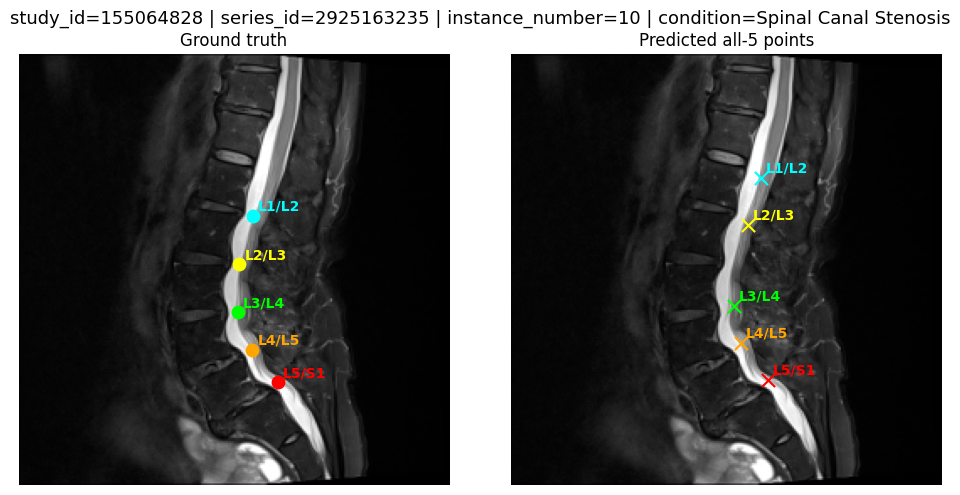

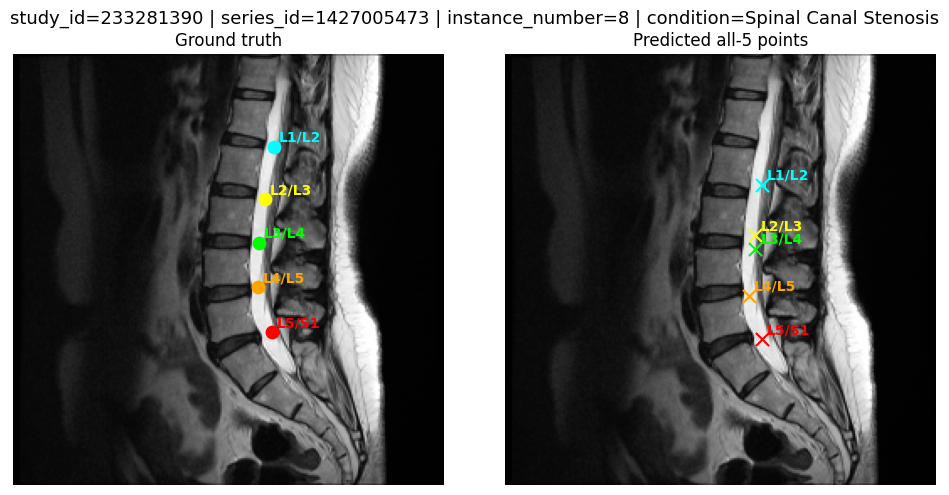

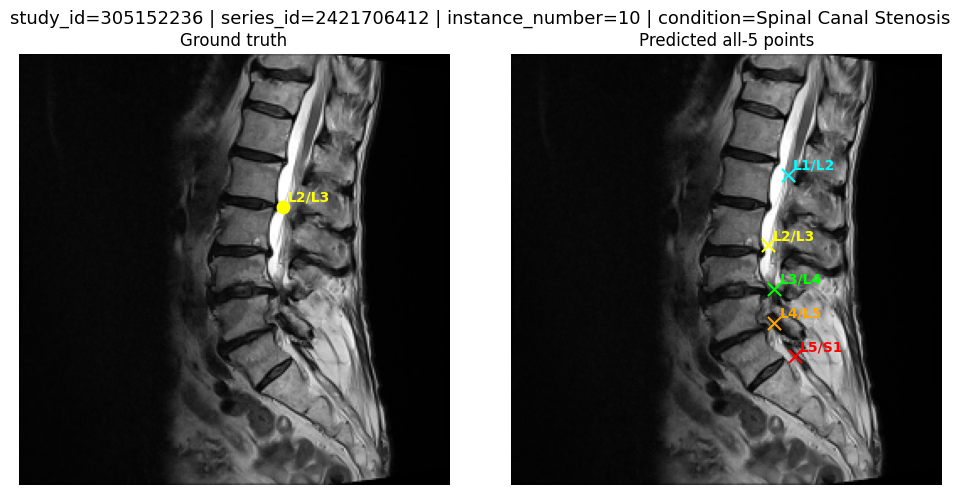

In [33]:
for _, row in critical_instances_with_anchor.dropna(subset=["anchor_idx"]).head(3).iterrows():
    anchor_idx = int(row["anchor_idx"])

    plot_study_gt_vs_predictions(
        study_id=row["study_id"],
        dataset=test_ds,
        pred_df=test_all5_pred_df,
        condition_filter=row["condition"],
        series_id=row["series_id"],
        instance_number=row["instance_number"],
        levels=LEVELS, 
        figsize=(10,5)
    )

In [34]:
TOL = EVAL_TOLERANCE_PX

# 1) Bad predictions: annotated rows outside 10px
bad_pred_df = eval_all5[
    (eval_all5["has_gt"]) &
    (eval_all5["dist_px"] > TOL)
].copy()

print("Bad annotated predictions outside 10px:", len(bad_pred_df))

group_cols = [
    c for c in ["study_id", "series_id", "instance_number", "condition"]
    if c in bad_pred_df.columns and c in group_diag_euclid_df.columns
]

bad_pred_with_diag = bad_pred_df.merge(
    group_diag_euclid_df[
        group_cols + [
            "diagnosis_bad",
            "order_ok",
            "euclidean_spacing_ok",
            "n_order_bad_pairs",
            "n_ratio_bad_pairs",
            "predicted_order_by_y",
        ]
    ],
    on=group_cols,
    how="left",
)

n_bad = len(bad_pred_with_diag)
n_caught = int(bad_pred_with_diag["diagnosis_bad"].fillna(False).sum())
n_missed = n_bad - n_caught

print(f"Bad predictions outside {int(TOL)}px: {n_bad}")
print(f"Caught by diagnosis:             {n_caught}")
print(f"Missed by diagnosis:             {n_missed}")

if n_bad > 0:
    print(f"Catch rate:                      {n_caught / n_bad * 100:.2f}%")

Bad annotated predictions outside 10px: 201
Bad predictions outside 10px: 201
Caught by diagnosis:             175
Missed by diagnosis:             26
Catch rate:                      87.06%


In [35]:
missed_bad_pred_df = bad_pred_with_diag[
    ~bad_pred_with_diag["diagnosis_bad"].fillna(False)
].copy()

missed_bad_pred_df[
    [
        "study_id", "series_id", "instance_number", "condition",
        "level", "pred_x", "pred_y", "gt_x", "gt_y",
        "dist_px", "order_ok", "euclidean_spacing_ok"
    ]
].sort_values("dist_px", ascending=False).head(3)

# One row per missed image/instance group
group_cols = [
    c for c in ["study_id", "series_id", "instance_number", "condition"]
    if c in missed_bad_pred_df.columns
]

missed_groups_for_viz = (
    missed_bad_pred_df[group_cols]
    .drop_duplicates()
    .reset_index(drop=True)
)


## 10. Hard correction of incorrect predictions

In [36]:
corrected_all5_pred_df, correction_report_df = correct_using_union_raw_heatmaps_top3(
    test_all5_pred_df=test_all5_pred_df,
    group_diag_euclid_df=group_diag_euclid_df,
    euclidean_ratio_constraints=euclidean_ratio_constraints,
    raw_heatmaps=raw_heatmaps,
    top_k=CORRECTION_TOP_K,
    nms_radius=CORRECTION_NMS_RADIUS,
    min_candidate_score=CORRECTION_MIN_CANDIDATE_SCORE,
    union_mode=CORRECTION_UNION_MODE,
    only_diagnosis_bad=True,
    tol=EVAL_TOLERANCE_PX
)

Correcting from union raw heatmaps:   0%|          | 0/136 [00:00<?, ?it/s]

In [37]:
actually_corrected_anchors = (
    correction_report_df.loc[
        correction_report_df["status"].str.startswith("auto_corrected", na=False),
        "anchor_idx"
    ]
    .dropna()
    .astype(int)
    .unique()
)

print("Actually corrected anchors:", len(actually_corrected_anchors))

Actually corrected anchors: 135


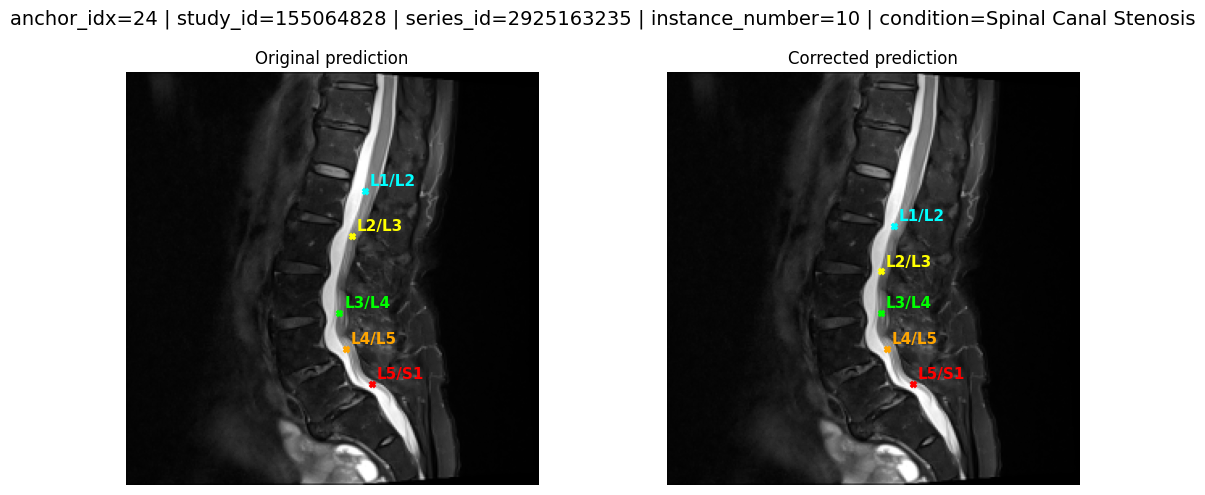

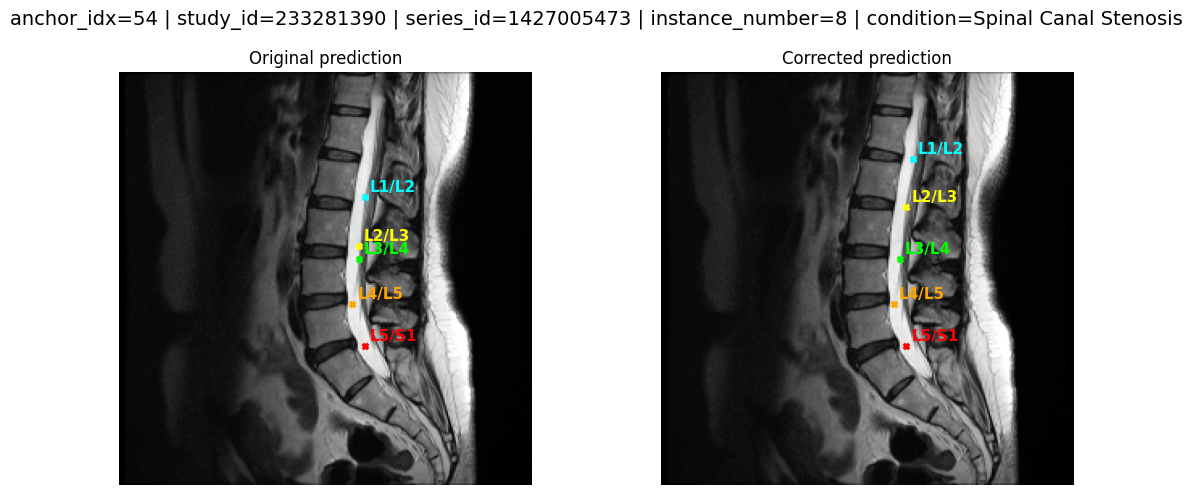

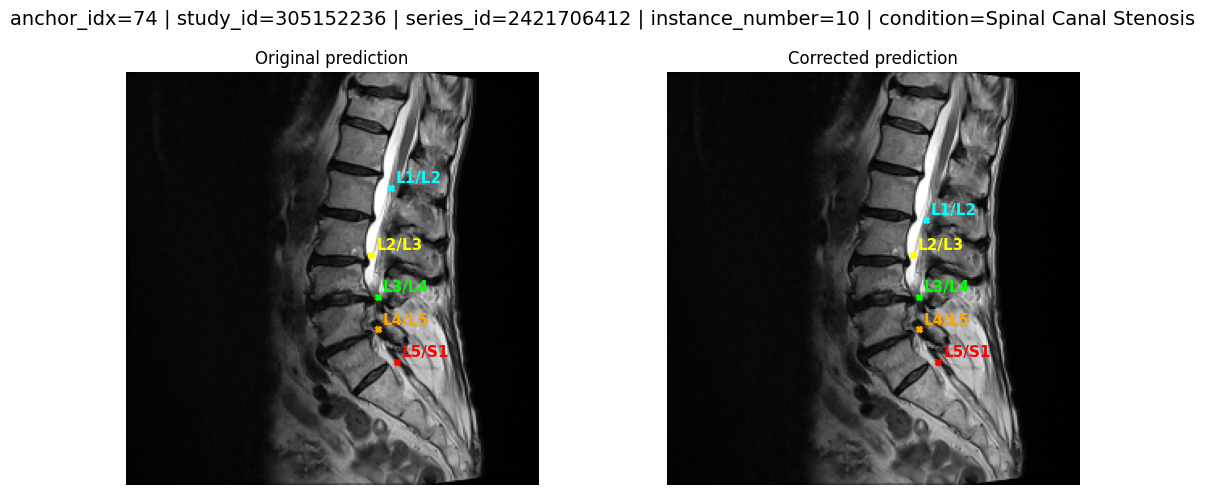

In [38]:
for anchor_idx in actually_corrected_anchors[:3]:
    plot_original_vs_corrected_predictions_by_anchor(
        anchor_idx=anchor_idx,
        original_pred_df=test_all5_pred_df,
        corrected_pred_df=corrected_all5_pred_df,
        dataset=test_ds,
        figsize=(11,5),
        marker_size=15
    )

In [39]:
correction_report_df["status"].value_counts()

status
auto_corrected_too_distant    180
started_case                  135
auto_corrected_wrong_order     71
auto_corrected_too_close       22
kept_valid                     11
no_bad_adjacent_pair_found      1
Name: count, dtype: int64

In [40]:
full_corrected_eval_df, overall_summary_df, level_summary_df = evaluate_full_test_with_corrected_coords(
    test_eval_df=test_eval_df,
    corrected_all5_pred_df=corrected_all5_pred_df,
    threshold=EVAL_TOLERANCE_PX,
)

display(overall_summary_df)
display(level_summary_df)

,n_predictions,original_correct_within_10px,original_incorrect_outside_10px,original_hit_rate,original_mean_dist_px,original_median_dist_px,final_correct_within_10px,final_incorrect_outside_10px,final_hit_rate,final_mean_dist_px,final_median_dist_px,fixed_bad_to_good,broken_good_to_bad,still_bad,still_good
0,1459,1255,204,0.860178,7.469632,4.853703,1414,45,0.969157,4.933586,4.334217,164,5,40,1250


,n,original_within_10px,original_hit_rate,original_mean_dist,original_median_dist,final_within_10px,final_hit_rate,final_mean_dist,final_median_dist,fixed_gain,hit_rate_gain
level,,,,,,,,,,,
L1/L2,284,194,0.683099,12.046302,7.008363,272,0.957746,5.498733,5.128500,78,0.274648
L2/L3,290,204,0.703448,11.490068,6.678806,281,0.968966,5.391143,5.054220,77,0.265517
L3/L4,296,285,0.962838,4.129797,3.413645,289,0.976351,3.864793,3.387858,4,0.013514
L4/L5,294,287,0.976190,4.525070,4.196219,287,0.976190,4.547341,4.196219,0,0.000000
L5/S1,295,285,0.966102,5.397062,4.480931,285,0.966102,5.397062,4.480931,0,0.000000
